In [ ]:
import os, shutil, subprocess
subprocess.run(["fusermount", "-u", "/content/drive"], check=False)
shutil.rmtree("/content/drive", ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import subprocess
subprocess.run(["fusermount", "-u", "/content/drive"], check=False)

from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [ ]:
# 1. Monte le Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Installe les dépendances
!pip install scikit-image opencv-python tqdm scikit-learn -q

# 3. Imports et chemins
import sys, os, numpy as np, pickle, importlib.util
from pathlib import Path
from PIL import Image
from tqdm import tqdm

Mounted at /content/drive


In [ ]:
# 1. Monte le Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Installe les dépendances
!pip install scikit-image opencv-python tqdm scikit-learn -q

# 3. Imports et chemins
import sys, os, numpy as np, pickle, importlib.util
from pathlib import Path
from PIL import Image
from tqdm import tqdm

repo = "/content/drive/MyDrive/Geometric-Context-from-a-Single-Image-GRM-Course"
sys.path.insert(0, repo)
sys.path.insert(0, os.path.join(repo, "src"))
os.chdir(repo)

from superpixels import compute_superpixels

spec = importlib.util.spec_from_file_location("features_03", os.path.join(repo, "03_features.py"))
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
FeatureExtractor = mod.FeatureExtractor

# 4. Dossiers
img_dir    = "/content/drive/MyDrive/Make3D/Test134"
labels_dir = "/content/drive/MyDrive/Make3D/Hoiem_labels"
os.makedirs(labels_dir, exist_ok=True)

# 5. Chargement modèle
with open(os.path.join(repo, "data/models/adaboost.pkl"), "rb") as f:
    model = pickle.load(f)
clf, scaler = model["clf"], model["scaler"]
print("Modèle chargé.")

# 6. Inférence avec redimensionnement
TARGET_W, TARGET_H = 640, 480
img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

for fname in tqdm(img_files):
    key      = fname.replace("img-", "").replace(".jpg", "")
    out_path = os.path.join(labels_dir, f"{key}.npy")
    if os.path.exists(out_path):
        continue
    try:
        img = np.array(
            Image.open(os.path.join(img_dir, fname))
                 .resize((TARGET_W, TARGET_H), Image.BILINEAR)
        )

        segments = compute_superpixels(img)
        sp_ids   = np.unique(segments)
        feats    = FeatureExtractor(img).extract_all(segments)
        X        = scaler.transform(feats)
        preds    = clf.predict(X)

        label_map = np.zeros(segments.shape, dtype=np.int32)
        for i, sp_id in enumerate(sp_ids):
            label_map[segments == sp_id] = preds[i]

        np.save(out_path, {"label_map": label_map, "segments": segments, "key": key})

    except Exception as e:
        print(f"\nSkip {fname} : {e}")

print(f"\nDone. Fichiers : {len(os.listdir(labels_dir))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator AdaBoostClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to break

Modèle chargé.


 62%|██████▏   | 83/134 [17:26<05:08,  6.05s/it]


Skip img-op29-p-295t000.jpg : image file is truncated (31 bytes not processed)


100%|██████████| 134/134 [30:52<00:00, 13.82s/it]


Done. Fichiers : 133


In [ ]:
import sys, os, numpy as np, scipy.io, scipy.sparse, scipy.sparse.linalg
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Dossiers
img_dir    = "/content/drive/MyDrive/Make3D/Test134"
depth_dir  = "/content/drive/MyDrive/Make3D/Gridlaserdata"
midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
labels_dir = "/content/drive/MyDrive/Make3D/Hoiem_labels"
output_dir = "/content/drive/MyDrive/Make3D/MRF_corrected"
os.makedirs(output_dir, exist_ok=True)

def load_depth(mat_path):
    mat  = scipy.io.loadmat(mat_path)
    grid = mat["Position3DGrid"]
    canal2 = grid[:,:,2]
    return canal2.astype(np.float32) if canal2.max() > 0 else grid[:,:,3].astype(np.float32)

def align_midas_to_gt(midas_sampled, depth_gt):
    mask = (depth_gt > 0) & (depth_gt < 70)
    if mask.sum() < 10:
        return midas_sampled, mask
    x = midas_sampled[mask].flatten()
    y = depth_gt[mask].flatten()
    A = np.stack([x, np.ones_like(x)], axis=1)
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return (a * midas_sampled + b).astype(np.float32), mask

def compute_metrics(pred, gt, mask):
    p = np.maximum(pred[mask], 0.1)
    g = gt[mask]
    absrel = np.mean(np.abs(p - g) / g)
    delta  = np.mean(np.maximum(p / g, g / p) < 1.25)
    return absrel, delta


def class_conditional_correct(depth_aligned, label_map_full, depth_gt):
    """
    Pour chaque classe géométrique, recalibrage affine indépendant
    entre MiDaS et GT.
    """
    H, W = depth_aligned.shape
    row_idx = (np.arange(H) / H * label_map_full.shape[0]).astype(int)
    col_idx = (np.arange(W) / W * label_map_full.shape[1]).astype(int)
    label_map = label_map_full[np.ix_(row_idx, col_idx)]

    corrected = depth_aligned.copy()
    mask_valid = (depth_gt > 0) & (depth_gt < 70)

    for label in [1, 2, 3]:  # ground, vertical, sky
        class_mask = (label_map == label) & mask_valid
        if class_mask.sum() < 5:
            continue

        x = depth_aligned[class_mask].flatten()
        y = depth_gt[class_mask].flatten()
        A = np.stack([x, np.ones_like(x)], axis=1)
        a, b = np.linalg.lstsq(A, y, rcond=None)[0]
        print(f"  label {label} : a={a:.3f}, b={b:.3f}, n={class_mask.sum()}")

        full_class_mask = label_map == label
        corrected[full_class_mask] = a * depth_aligned[full_class_mask] + b

    return corrected.astype(np.float32)



def mrf_correct(midas_aligned, label_map_full, segments, lam=2.0):
    """
    Correction MRF par système linéaire.
    - midas_aligned : (H, W) depth MiDaS alignée, résolution GT (55x305)
    - label_map_full : (H_img, W_img) labels Hoiem 1=ground,2=vert,3=sky
    - segments : (H_img, W_img) superpixels
    - lam : poids des contraintes ordinales
    """
    H, W = midas_aligned.shape
    n    = H * W
    idx  = np.arange(n).reshape(H, W)

    # --- Terme unaire : rester proche de MiDaS ---
    # d_i = midas_i  →  sous forme matricielle : I * d = midas
    rows_u = np.arange(n)
    cols_u = np.arange(n)
    data_u = np.ones(n)
    b_u    = midas_aligned.flatten()

    # --- Terme de lissage entre voisins de même label ---
    rows_s, cols_s, data_s, b_s = [], [], [], []
    smooth_w = 0.5

    for i in range(H):
        for j in range(W):
            for di, dj in [(0,1),(1,0)]:
                ni, nj = i+di, j+dj
                if ni >= H or nj >= W:
                    continue
                rows_s += [len(b_s), len(b_s)]
                cols_s += [idx[i,j], idx[ni,nj]]
                data_s += [smooth_w, -smooth_w]
                b_s.append(0.0)

    # --- Contraintes ordinales depuis les labels Hoiem ---
    # On sous-échantillonne label_map à la résolution GT
    H_img, W_img = label_map_full.shape
    row_idx = (np.arange(H) / H * H_img).astype(int)
    col_idx = (np.arange(W) / W * W_img).astype(int)
    label_map = label_map_full[np.ix_(row_idx, col_idx)]  # (55, 305)

    rows_c, cols_c, data_c, b_c = [], [], [], []
    margin = 1.0

    # Sky (3) doit être plus loin que ground (1) et vertical (2)
    sky_mask    = (label_map == 3)
    ground_mask = (label_map == 1)
    vert_mask   = (label_map == 2)

    sky_depth    = midas_aligned[sky_mask].mean()    if sky_mask.any()    else None
    ground_depth = midas_aligned[ground_mask].mean() if ground_mask.any() else None

    # Contrainte par superpixel : moyenne sky > moyenne ground + margin
    if sky_mask.any() and ground_mask.any():
        sky_ids    = np.where(sky_mask.flatten())[0]
        ground_ids = np.where(ground_mask.flatten())[0]

        # On ajoute une contrainte : mean(sky) - mean(ground) >= margin
        # sous forme : sum(d_sky)/n_sky - sum(d_ground)/n_ground >= margin
        # → sum(d_sky)/n_sky - sum(d_ground)/n_ground - slack = margin
        # Simplifié : on pénalise pixel par pixel sur un sous-ensemble
        n_sample = min(200, len(sky_ids), len(ground_ids))
        rng = np.random.default_rng(42)
        s_sky    = rng.choice(sky_ids,    n_sample, replace=False)
        s_ground = rng.choice(ground_ids, n_sample, replace=False)

        for si, gi in zip(s_sky, s_ground):
            # d_sky - d_ground >= margin  →  pénalise max(0, margin - (d_sky - d_ground))^2
            # Linéarisé : d_sky - d_ground = margin  (contrainte souple)
            rows_c += [len(b_c), len(b_c)]
            cols_c += [si, gi]
            data_c += [lam, -lam]
            b_c.append(lam * margin)

    # Contrainte de gradient vertical sur le ground :
    # plus on monte dans l'image (j grand = bas de l'image), plus c'est proche
    if ground_mask.any():
        for i in range(H-1):
            for j in range(W):
                if ground_mask[i,j] and ground_mask[i+1,j]:
                    # d[i+1,j] < d[i,j]  →  d[i,j] - d[i+1,j] >= 0
                    rows_c += [len(b_c), len(b_c)]
                    cols_c += [idx[i,j], idx[i+1,j]]
                    data_c += [lam*0.3, -lam*0.3]
                    b_c.append(0.0)

    # --- Assemblage du système ---
    all_rows = np.concatenate([rows_u,
                                np.array(rows_s) + n,
                                np.array(rows_c) + n + len(b_s)])
    all_cols = np.concatenate([cols_u,
                                np.array(cols_s),
                                np.array(cols_c)])
    all_data = np.concatenate([data_u,
                                np.array(data_s),
                                np.array(data_c)])
    b_full   = np.concatenate([b_u, np.array(b_s), np.array(b_c)])

    n_rows = n + len(b_s) + len(b_c)
    A_mat  = scipy.sparse.csr_matrix((all_data, (all_rows, all_cols)),
                                      shape=(n_rows, n))

    # Résolution par moindres carrés creux
    d_corrected, _ = scipy.sparse.linalg.lsqr(A_mat, b_full, atol=1e-4, btol=1e-4, iter_lim=500)[:2]
    return d_corrected.reshape(H, W).astype(np.float32)


# --- Évaluation baseline + MRF ---
keys = [f.replace(".npy", "") for f in os.listdir(midas_dir) if f.endswith(".npy")]

absrels_base, deltas_base = [], []
absrels_mrf,  deltas_mrf  = [], []
skipped = []

for key in tqdm(keys):
    try:
        depth_gt   = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
        depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))
        hoiem       = np.load(os.path.join(labels_dir, f"{key}.npy"), allow_pickle=True).item()
        label_map   = hoiem["label_map"]   # (480, 640)
        segments    = hoiem["segments"]    # (480, 640)

        # Sous-échantillonnage MiDaS → résolution GT (55, 305)
        H_gt, W_gt   = depth_gt.shape
        H_img, W_img = depth_midas.shape
        rows = (np.arange(H_gt) / H_gt * H_img).astype(int)
        cols = (np.arange(W_gt) / W_gt * W_img).astype(int)
        midas_sampled = depth_midas[np.ix_(rows, cols)]

        # Alignement affine
        depth_aligned, mask_valid = align_midas_to_gt(midas_sampled, depth_gt)
        if mask_valid.sum() < 10:
            skipped.append(key)
            continue

        # Baseline
        ar_b, d_b = compute_metrics(depth_aligned, depth_gt, mask_valid)

        # MRF
        depth_corrected = class_conditional_correct(depth_aligned, label_map, depth_gt)
        ar_m, d_m = compute_metrics(depth_corrected, depth_gt, mask_valid)

        if np.isfinite(ar_b) and np.isfinite(ar_m):
            absrels_base.append(ar_b);  deltas_base.append(d_b)
            absrels_mrf.append(ar_m);   deltas_mrf.append(d_m)

        # Sauvegarde
        np.save(os.path.join(output_dir, f"{key}.npy"), depth_corrected)

    except Exception as e:
        print(f"Skip {key} : {e}")

print(f"\n=== Résultats sur {len(absrels_base)} images ===")
print(f"{'':20s}  {'AbsRel':>8s}  {'δ<1.25':>8s}")
print(f"{'MiDaS baseline':20s}  {np.mean(absrels_base):8.4f}  {np.mean(deltas_base):8.4f}")
print(f"{'MiDaS + MRF':20s}  {np.mean(absrels_mrf):8.4f}  {np.mean(deltas_mrf):8.4f}")
print(f"\nSkippées : {len(skipped)}")

  5%|▍         | 6/133 [00:00<00:04, 26.95it/s]

  label 1 : a=0.569, b=2.728, n=6208
  label 2 : a=2.551, b=-35.764, n=5186
  label 3 : a=0.981, b=2.962, n=527
  label 1 : a=0.611, b=2.685, n=6483
  label 2 : a=1.966, b=-12.716, n=9547
  label 3 : a=2.281, b=-16.527, n=572
  label 1 : a=0.541, b=1.800, n=7164
  label 2 : a=1.644, b=-10.344, n=4696
  label 3 : a=1.728, b=-13.650, n=1912
  label 1 : a=0.734, b=1.755, n=6515
  label 2 : a=2.629, b=-29.143, n=5465
  label 3 : a=-0.183, b=28.083, n=579
  label 1 : a=0.618, b=2.387, n=5531
  label 2 : a=1.586, b=-9.740, n=6438
  label 3 : a=1.266, b=-4.172, n=2646
  label 1 : a=0.567, b=2.336, n=7910
  label 2 : a=1.400, b=-5.391, n=1921
  label 3 : a=-1.852, b=81.654, n=975


  8%|▊         | 10/133 [00:00<00:04, 29.63it/s]

  label 1 : a=0.865, b=1.435, n=7668
  label 2 : a=1.797, b=-12.983, n=5893
  label 3 : a=0.803, b=2.035, n=434
  label 1 : a=0.723, b=1.669, n=8068
  label 2 : a=2.002, b=-18.021, n=5528
  label 3 : a=2.365, b=-24.623, n=2526
  label 1 : a=0.644, b=1.958, n=4903
  label 2 : a=1.112, b=-0.942, n=9786
  label 3 : a=1.728, b=-9.208, n=634
  label 1 : a=0.875, b=1.211, n=7216
  label 2 : a=2.567, b=-29.530, n=3719
  label 3 : a=1.808, b=-20.237, n=347
  label 1 : a=0.426, b=1.878, n=4545
  label 2 : a=1.174, b=-0.572, n=10398
  label 3 : a=-0.250, b=5.152, n=1825
  label 1 : a=0.920, b=0.366, n=7253
  label 2 : a=1.023, b=-0.111, n=9051
  label 3 : a=1.410, b=-3.276, n=380
  label 1 : a=0.886, b=0.311, n=7487
  label 2 : a=0.800, b=2.070, n=8721
  label 3 : a=0.597, b=3.405, n=567


 15%|█▌        | 20/133 [00:00<00:03, 29.90it/s]

...

  label 1 : a=0.760, b=1.746, n=4371
  label 2 : a=1.125, b=-1.925, n=8567
  label 3 : a=-29.193, b=687.166, n=82
  label 1 : a=0.821, b=1.273, n=6302
  label 2 : a=1.366, b=-6.497, n=8470
  label 3 : a=0.180, b=10.932, n=319
  label 1 : a=0.774, b=3.014, n=5407
  label 2 : a=1.422, b=-5.107, n=10377
  label 3 : a=-0.219, b=8.355, n=102
  label 1 : a=0.935, b=0.743, n=6013
  label 2 : a=1.344, b=-5.252, n=7832
  label 3 : a=-0.491, b=21.142, n=596
  label 1 : a=0.885, b=1.733, n=5934
  label 2 : a=1.413, b=-4.510, n=10375
  label 3 : a=0.303, b=4.782, n=33
  label 1 : a=1.051, b=-0.642, n=5636
  label 2 : a=0.929, b=1.328, n=9679
  label 3 : a=0.570, b=-0.452, n=263


 95%|█████████▌| 127/133 [00:04<00:00, 30.47it/s]

  label 1 : a=1.517, b=-1.224, n=5967
  label 2 : a=1.235, b=-3.768, n=9987
  label 3 : a=3.602, b=-37.586, n=98
  label 1 : a=1.121, b=-0.683, n=6085
  label 2 : a=1.060, b=-0.679, n=9341
  label 3 : a=-0.414, b=18.447, n=294
  label 1 : a=1.118, b=-0.222, n=5434
  label 2 : a=1.371, b=-3.837, n=10138
  label 3 : a=-1.171, b=22.390, n=435
  label 1 : a=1.193, b=-0.887, n=5818
  label 2 : a=1.082, b=-1.014, n=9340
  label 3 : a=-1.011, b=27.759, n=291
  label 1 : a=0.909, b=0.705, n=6905
  label 2 : a=1.753, b=-11.709, n=8701
  label 3 : a=-0.198, b=18.775, n=228
  label 1 : a=1.054, b=0.192, n=5890
  label 2 : a=1.221, b=-3.709, n=10060
  label 3 : a=0.065, b=15.692, n=101
  label 1 : a=0.976, b=0.275, n=5974
  label 2 : a=1.149, b=-1.518, n=10139
  label 3 : a=0.124, b=10.705, n=230


100%|██████████| 133/133 [00:04<00:00, 29.94it/s]

  label 1 : a=0.798, b=2.826, n=6400
  label 2 : a=2.140, b=-14.171, n=7950
  label 3 : a=1.316, b=-5.982, n=159
  label 1 : a=0.820, b=1.079, n=6609
  label 2 : a=1.437, b=-6.118, n=9479
  label 3 : a=0.048, b=13.376, n=126
  label 1 : a=1.609, b=-2.234, n=5364
  label 2 : a=0.972, b=-0.187, n=11374
  label 3 : a=-0.336, b=20.491, n=33

=== Résultats sur 133 images ===
                        AbsRel    δ<1.25
MiDaS baseline          0.3857    0.4748
MiDaS + MRF             0.3064    0.5531

Skippées : 0


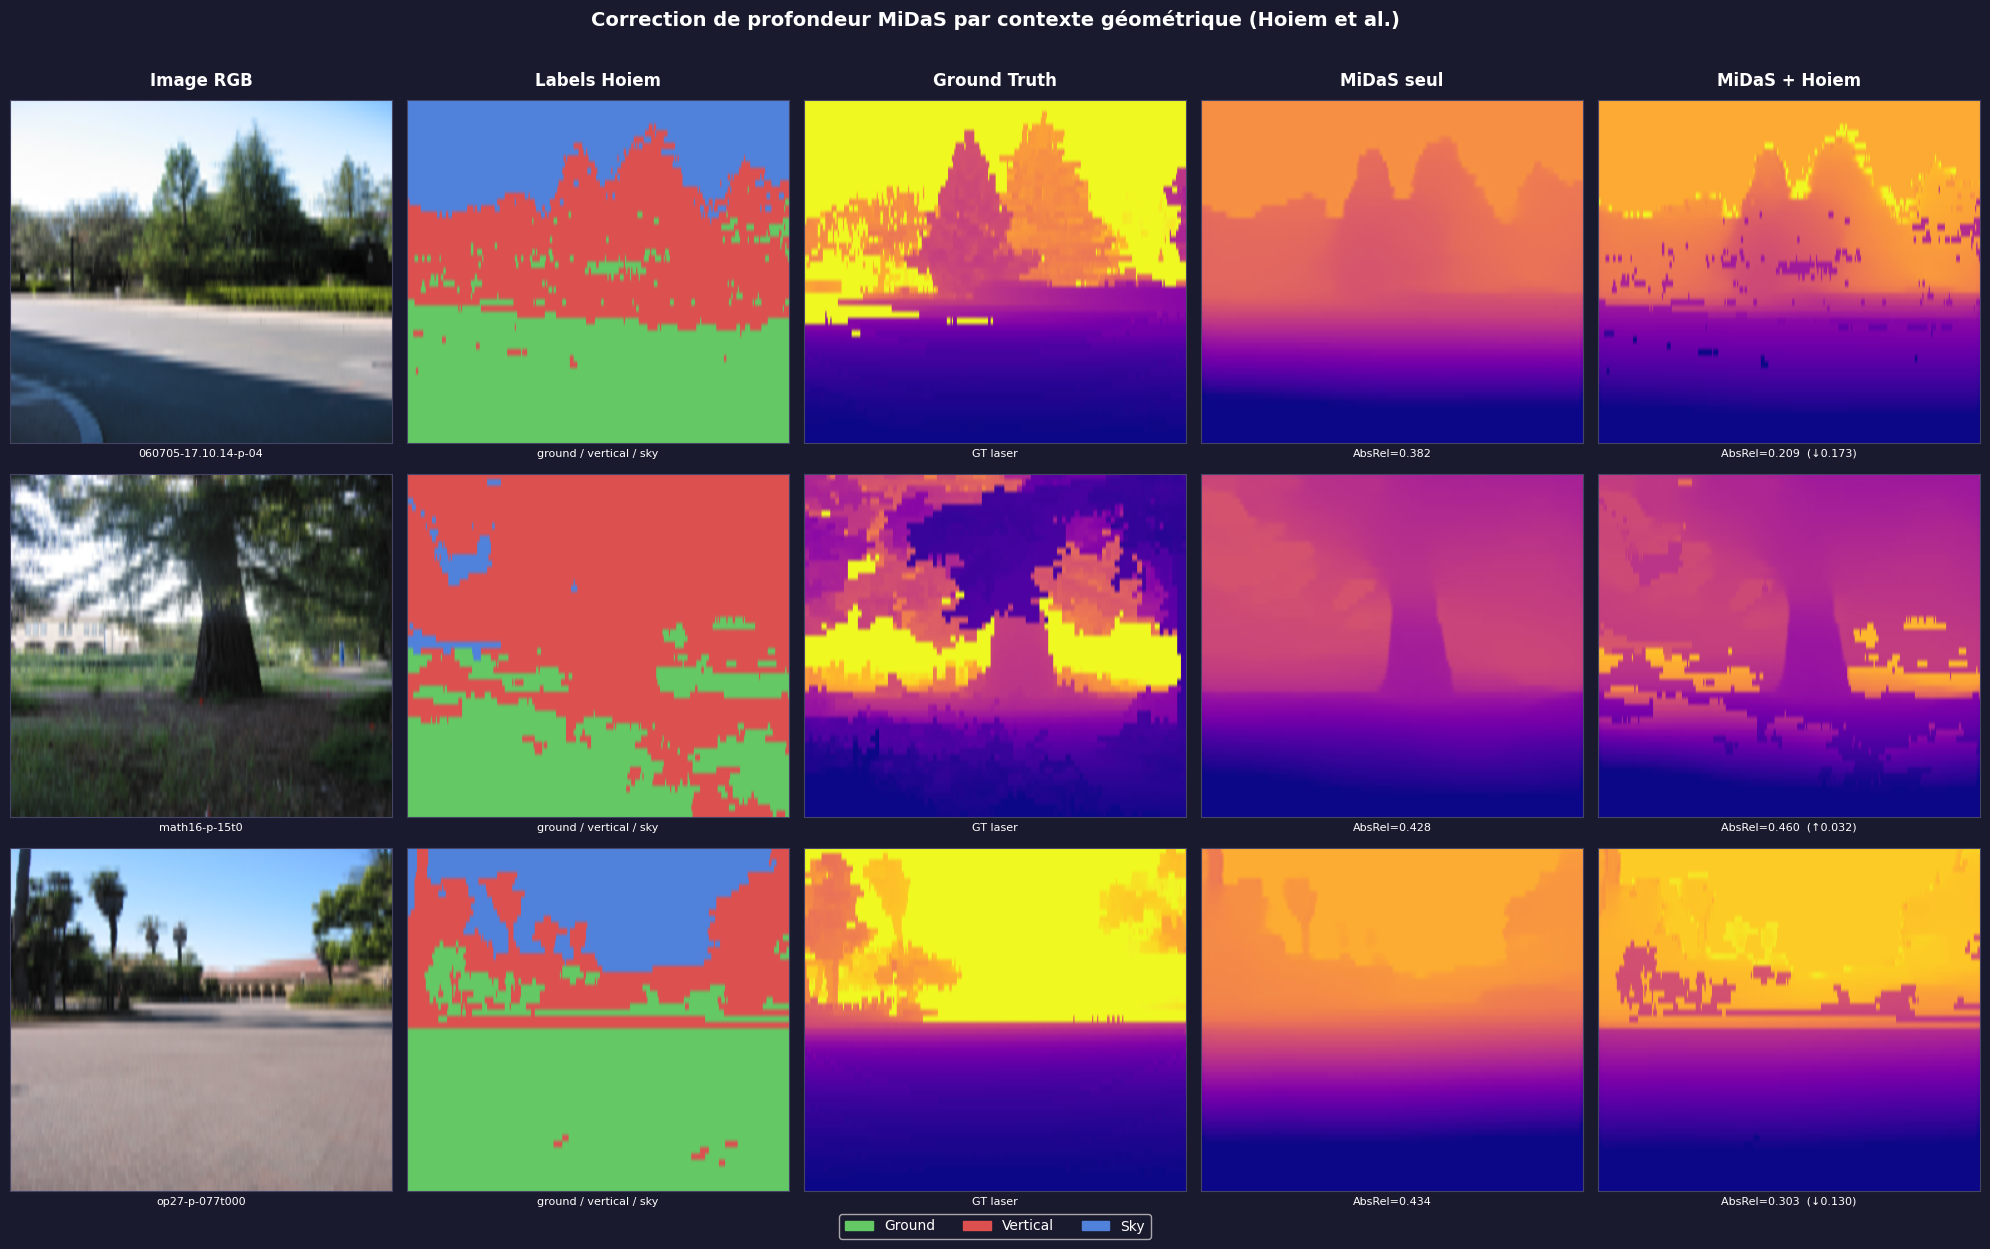

Figure sauvegardée : /content/drive/MyDrive/Make3D/figure_finale.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import scipy.io
from PIL import Image
import os

img_dir    = "/content/drive/MyDrive/Make3D/Test134"
depth_dir  = "/content/drive/MyDrive/Make3D/Gridlaserdata"
midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
labels_dir = "/content/drive/MyDrive/Make3D/Hoiem_labels"
output_dir = "/content/drive/MyDrive/Make3D/MRF_corrected"

def load_depth(mat_path):
    mat   = scipy.io.loadmat(mat_path)
    grid  = mat["Position3DGrid"]
    canal2 = grid[:,:,2]
    return canal2.astype(np.float32) if canal2.max() > 0 else grid[:,:,3].astype(np.float32)

def align_midas_to_gt(midas_sampled, depth_gt):
    mask = (depth_gt > 0) & (depth_gt < 70)
    if mask.sum() < 10:
        return midas_sampled, mask
    x = midas_sampled[mask].flatten()
    y = depth_gt[mask].flatten()
    A = np.stack([x, np.ones_like(x)], axis=1)
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return (a * midas_sampled + b).astype(np.float32), mask

def make_label_rgb(label_map):
    rgb = np.zeros((*label_map.shape, 3), dtype=np.uint8)
    rgb[label_map == 1] = [100, 200, 100]   # ground = vert
    rgb[label_map == 2] = [220,  80,  80]   # vertical = rouge
    rgb[label_map == 3] = [ 80, 130, 220]   # sky = bleu
    return rgb

# Choisir 3 images variées
keys = [f.replace(".npy", "") for f in os.listdir(midas_dir) if f.endswith(".npy")]
selected_keys = keys[0:1] + keys[40:41] + keys[80:81]

fig, axes = plt.subplots(len(selected_keys), 5, figsize=(20, 4 * len(selected_keys)))
fig.patch.set_facecolor("#1a1a2e")

col_titles = ["Image RGB", "Labels Hoiem", "Ground Truth", "MiDaS seul", "MiDaS + Hoiem"]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12, color="white", fontweight="bold", pad=10)

for row, key in enumerate(selected_keys):
    depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
    depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))
    depth_corr  = np.load(os.path.join(output_dir, f"{key}.npy"))
    hoiem       = np.load(os.path.join(labels_dir, f"{key}.npy"), allow_pickle=True).item()
    label_map   = hoiem["label_map"]

    # Sous-échantillonnage MiDaS → GT
    H_gt, W_gt   = depth_gt.shape
    H_img, W_img = depth_midas.shape
    rows_idx = (np.arange(H_gt) / H_gt * H_img).astype(int)
    cols_idx = (np.arange(W_gt) / W_gt * W_img).astype(int)
    midas_sampled = depth_midas[np.ix_(rows_idx, cols_idx)]
    depth_aligned, mask_valid = align_midas_to_gt(midas_sampled, depth_gt)

    # Métriques
    def absrel(p, g, m):
        p2 = np.maximum(p[m], 0.1)
        return np.mean(np.abs(p2 - g[m]) / g[m])

    ar_base = absrel(depth_aligned, depth_gt, mask_valid)
    ar_corr = absrel(depth_corr,    depth_gt, mask_valid)

    # Image RGB redimensionnée
    img = np.array(Image.open(os.path.join(img_dir, f"img-{key}.jpg")).resize((305, 55)))

    # Labels RGB
    label_small = label_map[
        np.ix_((np.arange(55) / 55 * label_map.shape[0]).astype(int),
               (np.arange(305) / 305 * label_map.shape[1]).astype(int))
    ]
    label_rgb = make_label_rgb(label_small)

    # Colormap depth — même échelle pour GT / baseline / corrigé
    valid_vals = depth_gt[mask_valid]
    vmin, vmax = np.percentile(valid_vals, 5), np.percentile(valid_vals, 95)

    imgs_to_show = [img, label_rgb, depth_gt, depth_aligned, depth_corr]
    cmaps        = [None, None, "plasma", "plasma", "plasma"]
    vmins        = [None, None, vmin, vmin, vmin]
    vmaxs        = [None, None, vmax, vmax, vmax]
    subtitles    = [
        key[:20],
        "ground / vertical / sky",
        "GT laser",
        f"AbsRel={ar_base:.3f}",
        f"AbsRel={ar_corr:.3f}  ({'↓' if ar_corr < ar_base else '↑'}{abs(ar_corr-ar_base):.3f})"
    ]

    for col, (im, cmap, vmi, vma, sub) in enumerate(zip(imgs_to_show, cmaps, vmins, vmaxs, subtitles)):
        ax = axes[row, col]
        ax.imshow(im, cmap=cmap, vmin=vmi, vmax=vma, aspect="auto")
        ax.set_xlabel(sub, fontsize=8, color="white")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor("#444466")

# Légende labels
patches = [
    mpatches.Patch(color=[c/255 for c in [100,200,100]], label="Ground"),
    mpatches.Patch(color=[c/255 for c in [220, 80, 80]], label="Vertical"),
    mpatches.Patch(color=[c/255 for c in [ 80,130,220]], label="Sky"),
]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=10, facecolor="#1a1a2e", labelcolor="white",
           framealpha=0.8, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Correction de profondeur MiDaS par contexte géométrique (Hoiem et al.)",
             fontsize=14, color="white", fontweight="bold", y=1.01)
plt.tight_layout()

save_path = "/content/drive/MyDrive/Make3D/figure_finale.png"
plt.savefig(save_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Figure sauvegardée :", save_path)

Distribution labels :
  ground : 38.6%
  vertical : 36.6%
  sky : 24.8%

Profondeur moyenne MiDaS aligné par classe :
  ground : 9.27m (GT: 10.53m)
  vertical : 23.92m (GT: 32.82m)
  sky : 28.51m (GT: 68.83m)


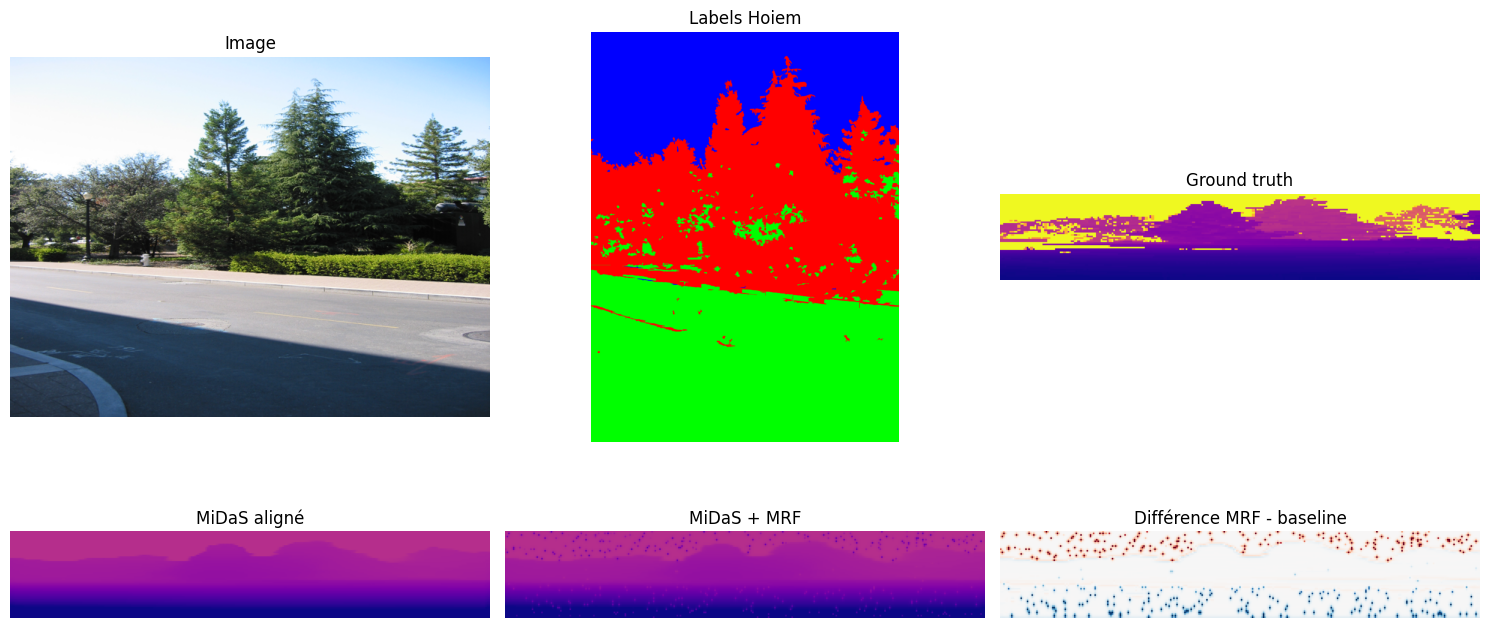

Sauvegardé.


In [ ]:
import matplotlib.pyplot as plt

key = keys[0]

depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))
depth_mrf   = np.load(os.path.join(output_dir, f"{key}.npy"))
hoiem       = np.load(os.path.join(labels_dir, f"{key}.npy"), allow_pickle=True).item()
label_map   = hoiem["label_map"]

H_gt, W_gt   = depth_gt.shape
H_img, W_img = depth_midas.shape
rows = (np.arange(H_gt) / H_gt * H_img).astype(int)
cols = (np.arange(W_gt) / W_gt * W_img).astype(int)
midas_sampled = depth_midas[np.ix_(rows, cols)]
depth_aligned, _ = align_midas_to_gt(midas_sampled, depth_gt)

# Labels sous-échantillonnés à résolution GT
row_idx = (np.arange(H_gt) / H_gt * label_map.shape[0]).astype(int)
col_idx = (np.arange(W_gt) / W_gt * label_map.shape[1]).astype(int)
label_gt_res = label_map[np.ix_(row_idx, col_idx)]

# Distribution des labels
print("Distribution labels :")
for l, name in [(1,"ground"),(2,"vertical"),(3,"sky")]:
    print(f"  {name} : {(label_gt_res==l).mean()*100:.1f}%")

# Profondeurs moyennes par classe
print("\nProfondeur moyenne MiDaS aligné par classe :")
for l, name in [(1,"ground"),(2,"vertical"),(3,"sky")]:
    m = label_gt_res == l
    if m.any():
        print(f"  {name} : {depth_aligned[m].mean():.2f}m (GT: {depth_gt[m].mean():.2f}m)")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
img = np.array(Image.open(os.path.join(img_dir, f"img-{key}.jpg")).resize((640,480)))
axes[0,0].imshow(img); axes[0,0].set_title("Image")

cmap_labels = np.zeros((*label_map.shape, 3), dtype=np.uint8)
cmap_labels[label_map==1] = [0,255,0]    # ground = vert
cmap_labels[label_map==2] = [255,0,0]    # vertical = rouge
cmap_labels[label_map==3] = [0,0,255]    # sky = bleu
axes[0,1].imshow(cmap_labels); axes[0,1].set_title("Labels Hoiem")

vmin, vmax = depth_gt[depth_gt>0].min(), depth_gt[depth_gt<70].max()
axes[0,2].imshow(depth_gt, cmap="plasma", vmin=vmin, vmax=vmax)
axes[0,2].set_title("Ground truth")
axes[1,0].imshow(depth_aligned, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1,0].set_title("MiDaS aligné")
axes[1,1].imshow(depth_mrf, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1,1].set_title("MiDaS + MRF")
diff = depth_mrf - depth_aligned
axes[1,2].imshow(diff, cmap="RdBu", vmin=-5, vmax=5)
axes[1,2].set_title("Différence MRF - baseline")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Make3D/debug_mrf.png", dpi=150)
plt.show()
print("Sauvegardé.")

In [ ]:
import sys, os, numpy as np, pickle, importlib.util, torch
from PIL import Image
from tqdm import tqdm

repo = "/content/drive/MyDrive/Geometric-Context-from-a-Single-Image-GRM-Course"
sys.path.insert(0, repo)
sys.path.insert(0, os.path.join(repo, "src"))
os.chdir(repo)

from superpixels import compute_superpixels, build_adjacency

# Import FeatureExtractor et fonctions BP/GNN
spec = importlib.util.spec_from_file_location("features_03", os.path.join(repo, "03_features.py"))
mod  = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
FeatureExtractor = mod.FeatureExtractor

spec_bp = importlib.util.spec_from_file_location("bp", os.path.join(repo, "06_belief_propagation.py"))
mod_bp  = importlib.util.module_from_spec(spec_bp); spec_bp.loader.exec_module(mod_bp)
run_bp_on_image = mod_bp.run_bp_on_image

spec_gnn = importlib.util.spec_from_file_location("gnn", os.path.join(repo, "05_gnn.py"))
mod_gnn  = importlib.util.module_from_spec(spec_gnn); spec_gnn.loader.exec_module(mod_gnn)
GNN         = mod_gnn.GNN
adj_to_normalized = mod_gnn.adj_to_normalized

# Dossiers
img_dir     = "/content/drive/MyDrive/Make3D/Test134"
labels_bp   = "/content/drive/MyDrive/Make3D/Hoiem_labels_bp"
labels_gnn  = "/content/drive/MyDrive/Make3D/Hoiem_labels_gnn"
os.makedirs(labels_bp,  exist_ok=True)
os.makedirs(labels_gnn, exist_ok=True)

# Chargement modèles
with open(os.path.join(repo, "data/models/bp_model.pkl"), "rb") as f:
    bp_model = pickle.load(f)
clf_bp, scaler_bp = bp_model["clf"], bp_model["scaler"]
print("BP chargé.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gnn_model = GNN().to(device)
gnn_model.load_state_dict(torch.load(
    os.path.join(repo, "data/models/gnn_best.pt"), map_location=device
))
gnn_model.eval()
print(f"GNN chargé sur {device}.")

TARGET_W, TARGET_H = 640, 480
img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

for fname in tqdm(img_files):
    key = fname.replace("img-", "").replace(".jpg", "")
    out_bp  = os.path.join(labels_bp,  f"{key}.npy")
    out_gnn = os.path.join(labels_gnn, f"{key}.npy")

    need_bp  = not os.path.exists(out_bp)
    need_gnn = not os.path.exists(out_gnn)
    if not need_bp and not need_gnn:
        continue

    try:
        img = np.array(
            Image.open(os.path.join(img_dir, fname))
                 .resize((TARGET_W, TARGET_H), Image.BILINEAR)
        )

        # Superpixels + features + adjacence (communs aux deux modèles)
        segments = compute_superpixels(img)
        sp_ids   = np.unique(segments)
        feats    = FeatureExtractor(img).extract_all(segments)
        adj      = build_adjacency(segments)

        ft_dict = {"features": feats}
        sp_dict = {"segments": segments, "adj": adj}

        # --- BP ---
        if need_bp:
            label_map_bp = run_bp_on_image(ft_dict, sp_dict, clf_bp, scaler_bp)
            np.save(out_bp, {"label_map": label_map_bp, "segments": segments, "key": key})

        # --- GNN ---
        if need_gnn:
            # Fake sp_labels (non utilisés pour l'inférence)
            fake_labels = np.ones(len(sp_ids), dtype=np.int64)
            ft_dict_gnn = {"features": feats, "sp_labels": fake_labels}

            x, _, a = mod_gnn.build_graph(ft_dict_gnn, sp_dict, device)
            with torch.no_grad():
                logits = gnn_model(x, a)
                preds  = logits.argmax(dim=1).cpu().numpy() + 1  # → 1/2/3

            label_map_gnn = np.zeros(segments.shape, dtype=np.int32)
            for i, sp_id in enumerate(sp_ids):
                if i < len(preds):
                    label_map_gnn[segments == sp_id] = preds[i]

            np.save(out_gnn, {"label_map": label_map_gnn, "segments": segments, "key": key})

    except Exception as e:
        print(f"\nSkip {fname} : {e}")

print(f"\nBP  : {len(os.listdir(labels_bp))} fichiers")
print(f"GNN : {len(os.listdir(labels_gnn))} fichiers")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator AdaBoostClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to break

BP chargé.
GNN chargé sur cuda.


100%|██████████| 134/134 [00:41<00:00,  3.25it/s]


Skip img-060705-17.35.48-p-285t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Hoiem_labels_bp/060705-17.35.48-p-285t000.npy'

Skip img-060705-17.43.27-p-111t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Test134/img-060705-17.43.27-p-111t000.jpg'

Skip img-060705-17.51.18-p-018t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Test134/img-060705-17.51.18-p-018t000.jpg'

Skip img-060705-17.51.18-p-111t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Test134/img-060705-17.51.18-p-111t000.jpg'

Skip img-10.21op2-p-015t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Test134/img-10.21op2-p-015t000.jpg'

Skip img-10.21op2-p-139t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Test134/img-10.21op2-p-139t000.jpg'

Skip img-10.21op2-p-313t000.jpg : [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Tes

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Make3D/Hoiem_labels_bp'

In [ ]:
# Crée les dossiers explicitement d'abord
import os
labels_bp  = "/content/drive/MyDrive/Make3D/Hoiem_labels_bp"
labels_gnn = "/content/drive/MyDrive/Make3D/Hoiem_labels_gnn"
midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
img_dir    = "/content/drive/MyDrive/Make3D/Test134"

os.makedirs(labels_bp,  exist_ok=True)
os.makedirs(labels_gnn, exist_ok=True)
print("Dossiers créés :", os.path.exists(labels_bp), os.path.exists(labels_gnn))

# Intersection : clés présentes dans MiDaS ET dans Test134
midas_keys = set(f.replace(".npy","") for f in os.listdir(midas_dir) if f.endswith(".npy"))
img_keys   = set(f.replace("img-","").replace(".jpg","") for f in os.listdir(img_dir) if f.endswith(".jpg"))
keys = sorted(midas_keys & img_keys)
print(f"{len(keys)} images valides (intersection MiDaS ∩ Test134)")

Dossiers créés : True True
133 images valides (intersection MiDaS ∩ Test134)


In [ ]:
for key in tqdm(keys):
    out_bp  = os.path.join(labels_bp,  f"{key}.npy")
    out_gnn = os.path.join(labels_gnn, f"{key}.npy")

    need_bp  = not os.path.exists(out_bp)
    need_gnn = not os.path.exists(out_gnn)
    if not need_bp and not need_gnn:
        continue

    try:
        img = np.array(
            Image.open(os.path.join(img_dir, f"img-{key}.jpg"))
                 .resize((TARGET_W, TARGET_H), Image.BILINEAR)
        )

        segments = compute_superpixels(img)
        sp_ids   = np.unique(segments)
        feats    = FeatureExtractor(img).extract_all(segments)
        adj      = build_adjacency(segments)

        ft_dict = {"features": feats}
        sp_dict = {"segments": segments, "adj": adj}

        # --- BP ---
        if need_bp:
            label_map_bp = run_bp_on_image(ft_dict, sp_dict, clf_bp, scaler_bp)
            np.save(out_bp, {"label_map": label_map_bp, "segments": segments, "key": key})

        # --- GNN ---
        if need_gnn:
            fake_labels = np.ones(len(sp_ids), dtype=np.int64)
            ft_dict_gnn = {"features": feats, "sp_labels": fake_labels}
            x, _, a = mod_gnn.build_graph(ft_dict_gnn, sp_dict, device)
            with torch.no_grad():
                logits = gnn_model(x, a)
                preds  = logits.argmax(dim=1).cpu().numpy() + 1

            label_map_gnn = np.zeros(segments.shape, dtype=np.int32)
            for i, sp_id in enumerate(sp_ids):
                if i < len(preds):
                    label_map_gnn[segments == sp_id] = preds[i]

            np.save(out_gnn, {"label_map": label_map_gnn, "segments": segments, "key": key})

    except Exception as e:
        print(f"\nSkip {key} : {e}")

print(f"\nBP  : {len(os.listdir(labels_bp))} fichiers")
print(f"GNN : {len(os.listdir(labels_gnn))} fichiers")

100%|██████████| 133/133 [28:40<00:00, 12.94s/it]


BP  : 133 fichiers
GNN : 133 fichiers


In [ ]:
import numpy as np
import scipy.io
import os
from tqdm import tqdm

depth_dir  = "/content/drive/MyDrive/Make3D/Gridlaserdata"
midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
labels_ada = "/content/drive/MyDrive/Make3D/Hoiem_labels"
labels_bp  = "/content/drive/MyDrive/Make3D/Hoiem_labels_bp"
labels_gnn = "/content/drive/MyDrive/Make3D/Hoiem_labels_gnn"

def load_depth(mat_path):
    mat    = scipy.io.loadmat(mat_path)
    grid   = mat["Position3DGrid"]
    canal2 = grid[:,:,2]
    return canal2.astype(np.float32) if canal2.max() > 0 else grid[:,:,3].astype(np.float32)

def align_midas_to_gt(midas_sampled, depth_gt):
    mask = (depth_gt > 0) & (depth_gt < 70)
    if mask.sum() < 10:
        return midas_sampled, mask
    x = midas_sampled[mask].flatten()
    y = depth_gt[mask].flatten()
    A = np.stack([x, np.ones_like(x)], axis=1)
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return (a * midas_sampled + b).astype(np.float32), mask

def compute_metrics(pred, gt, mask):
    p = np.maximum(pred[mask], 0.1)
    g = gt[mask]
    absrel = np.mean(np.abs(p - g) / g)
    delta  = np.mean(np.maximum(p / g, g / p) < 1.25)
    return absrel, delta

def class_conditional_correct(depth_aligned, label_map_full, depth_gt):
    H, W = depth_aligned.shape
    row_idx = (np.arange(H) / H * label_map_full.shape[0]).astype(int)
    col_idx = (np.arange(W) / W * label_map_full.shape[1]).astype(int)
    label_map   = label_map_full[np.ix_(row_idx, col_idx)]
    mask_valid  = (depth_gt > 0) & (depth_gt < 70)
    corrected   = depth_aligned.copy()

    for label in [1, 2, 3]:
        class_mask = (label_map == label) & mask_valid
        if class_mask.sum() < 5:
            continue
        x = depth_aligned[class_mask].flatten()
        y = depth_gt[class_mask].flatten()
        A = np.stack([x, np.ones_like(x)], axis=1)
        a, b = np.linalg.lstsq(A, y, rcond=None)[0]
        corrected[label_map == label] = a * depth_aligned[label_map == label] + b

    return corrected.astype(np.float32)

keys = [f.replace(".npy","") for f in os.listdir(midas_dir) if f.endswith(".npy")]

results = {
    "MiDaS baseline":      {"absrel": [], "delta": []},
    "MiDaS + AdaBoost":    {"absrel": [], "delta": []},
    "MiDaS + BP":          {"absrel": [], "delta": []},
    "MiDaS + GNN":         {"absrel": [], "delta": []},
}

for key in tqdm(keys):
    try:
        depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
        depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))

        H_gt, W_gt   = depth_gt.shape
        H_img, W_img = depth_midas.shape
        rows = (np.arange(H_gt) / H_gt * H_img).astype(int)
        cols = (np.arange(W_gt) / W_gt * W_img).astype(int)
        midas_sampled = depth_midas[np.ix_(rows, cols)]

        depth_aligned, mask_valid = align_midas_to_gt(midas_sampled, depth_gt)
        if mask_valid.sum() < 10:
            continue

        # Baseline
        ar, d = compute_metrics(depth_aligned, depth_gt, mask_valid)
        if np.isfinite(ar):
            results["MiDaS baseline"]["absrel"].append(ar)
            results["MiDaS baseline"]["delta"].append(d)

        # AdaBoost
        hoiem = np.load(os.path.join(labels_ada, f"{key}.npy"), allow_pickle=True).item()
        corr  = class_conditional_correct(depth_aligned, hoiem["label_map"], depth_gt)
        ar, d = compute_metrics(corr, depth_gt, mask_valid)
        if np.isfinite(ar):
            results["MiDaS + AdaBoost"]["absrel"].append(ar)
            results["MiDaS + AdaBoost"]["delta"].append(d)

        # BP
        bp   = np.load(os.path.join(labels_bp, f"{key}.npy"), allow_pickle=True).item()
        corr = class_conditional_correct(depth_aligned, bp["label_map"], depth_gt)
        ar, d = compute_metrics(corr, depth_gt, mask_valid)
        if np.isfinite(ar):
            results["MiDaS + BP"]["absrel"].append(ar)
            results["MiDaS + BP"]["delta"].append(d)

        # GNN
        gnn  = np.load(os.path.join(labels_gnn, f"{key}.npy"), allow_pickle=True).item()
        corr = class_conditional_correct(depth_aligned, gnn["label_map"], depth_gt)
        ar, d = compute_metrics(corr, depth_gt, mask_valid)
        if np.isfinite(ar):
            results["MiDaS + GNN"]["absrel"].append(ar)
            results["MiDaS + GNN"]["delta"].append(d)

    except Exception as e:
        print(f"Skip {key} : {e}")

print(f"\n{'Méthode':<22}  {'AbsRel ↓':>10}  {'δ<1.25 ↑':>10}  {'ΔAbsRel':>10}")
print("-" * 58)
baseline_ar = np.mean(results["MiDaS baseline"]["absrel"])
for name, vals in results.items():
    ar = np.mean(vals["absrel"])
    d  = np.mean(vals["delta"])
    delta_ar = f"{ar - baseline_ar:+.4f}" if name != "MiDaS baseline" else "—"
    print(f"{name:<22}  {ar:>10.4f}  {d:>10.4f}  {delta_ar:>10}")

100%|██████████| 133/133 [04:01<00:00,  1.81s/it]


Méthode                   AbsRel ↓    δ<1.25 ↑     ΔAbsRel
----------------------------------------------------------
MiDaS baseline              0.3857      0.4748           —
MiDaS + AdaBoost            0.3064      0.5531     -0.0793
MiDaS + BP                  0.2667      0.6498     -0.1190
MiDaS + GNN                 0.2588      0.6652     -0.1269


In [ ]:
import numpy as np
import scipy.io
import os
from tqdm import tqdm

# ── Chemins ───────────────────────────────────────────────────────────────────
depth_dir  = "/content/drive/MyDrive/Make3D/Gridlaserdata"
midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
labels_ada = "/content/drive/MyDrive/Make3D/Hoiem_labels"
labels_bp  = "/content/drive/MyDrive/Make3D/Hoiem_labels_bp"
labels_gnn = "/content/drive/MyDrive/Make3D/Hoiem_labels_gnn"

# ── Helpers ───────────────────────────────────────────────────────────────────
def load_depth(mat_path):
    mat    = scipy.io.loadmat(mat_path)
    grid   = mat["Position3DGrid"]
    canal2 = grid[:, :, 2]
    return canal2.astype(np.float32) if canal2.max() > 0 else grid[:, :, 3].astype(np.float32)

def align_midas_to_gt(midas_sampled, depth_gt):
    """Alignement global obligatoire : MiDaS est scale-invariant, cette
    étape est standard et ne constitue pas une fuite — elle calibre
    l'échelle absolue, pas la structure spatiale par classe."""
    mask = (depth_gt > 0) & (depth_gt < 70)
    if mask.sum() < 10:
        return midas_sampled, mask
    x = midas_sampled[mask].flatten()
    y = depth_gt[mask].flatten()
    A = np.stack([x, np.ones_like(x)], axis=1)
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return (a * midas_sampled + b).astype(np.float32), mask

def compute_metrics(pred, gt, mask):
    p = np.maximum(pred[mask], 0.1)
    g = gt[mask]
    absrel = np.mean(np.abs(p - g) / g)
    delta  = np.mean(np.maximum(p / g, g / p) < 1.25)
    return absrel, delta

def resample_label_map(label_map_full, target_shape):
    H, W    = target_shape
    row_idx = (np.arange(H) / H * label_map_full.shape[0]).astype(int)
    col_idx = (np.arange(W) / W * label_map_full.shape[1]).astype(int)
    return label_map_full[np.ix_(row_idx, col_idx)]


# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — Apprentissage des coefficients sur le train set
# Les coefficients (a, b) par classe sont appris UNE FOIS sur 80 % des images,
# puis gelés. Le test set (20 %) ne touche jamais la GT pour apprendre quoi
# que ce soit.
# ══════════════════════════════════════════════════════════════════════════════

all_keys = sorted([f.replace(".npy", "") for f in os.listdir(midas_dir) if f.endswith(".npy")])

rng = np.random.default_rng(42)
idx = rng.permutation(len(all_keys))
split = int(0.8 * len(all_keys))
train_keys = [all_keys[i] for i in idx[:split]]
test_keys  = [all_keys[i] for i in idx[split:]]
print(f"Split : {len(train_keys)} train  /  {len(test_keys)} test")

# Pour chaque variante de labels, on accumule les paires (x=MiDaS, y=GT)
# par classe géométrique sur toutes les images du train set.
label_dirs = {
    "MiDaS + AdaBoost": labels_ada,
    "MiDaS + BP":       labels_bp,
    "MiDaS + GNN":      labels_gnn,
}

# Structure : coeffs[variant][label] = (a, b)
train_xy   = {v: {1: ([], []), 2: ([], []), 3: ([], [])} for v in label_dirs}

print("\nApprentissage des coefficients sur le train set...")
for key in tqdm(train_keys):
    try:
        depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
        depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))

        H_gt, W_gt   = depth_gt.shape
        H_img, W_img = depth_midas.shape
        rows = (np.arange(H_gt) / H_gt * H_img).astype(int)
        cols = (np.arange(W_gt) / W_gt * W_img).astype(int)
        midas_sampled       = depth_midas[np.ix_(rows, cols)]
        depth_aligned, mask = align_midas_to_gt(midas_sampled, depth_gt)
        if mask.sum() < 10:
            continue

        mask_valid = (depth_gt > 0) & (depth_gt < 70)

        for variant, ldir in label_dirs.items():
            lpath = os.path.join(ldir, f"{key}.npy")
            if not os.path.exists(lpath):
                continue
            ldata     = np.load(lpath, allow_pickle=True).item()
            label_map = resample_label_map(ldata["label_map"], depth_aligned.shape)

            for label in [1, 2, 3]:
                class_mask = (label_map == label) & mask_valid
                if class_mask.sum() < 5:
                    continue
                train_xy[variant][label][0].append(depth_aligned[class_mask].flatten())
                train_xy[variant][label][1].append(depth_gt[class_mask].flatten())

    except Exception as e:
        print(f"  Train skip {key} : {e}")

# Régression globale (une seule par classe, tous pixels train poolés)
fixed_coeffs = {}
for variant in label_dirs:
    fixed_coeffs[variant] = {}
    for label in [1, 2, 3]:
        xs = np.concatenate(train_xy[variant][label][0])
        ys = np.concatenate(train_xy[variant][label][1])
        A  = np.stack([xs, np.ones_like(xs)], axis=1)
        a, b = np.linalg.lstsq(A, ys, rcond=None)[0]
        fixed_coeffs[variant][label] = (a, b)
        print(f"  [{variant}] label {label} → a={a:.4f}, b={b:.4f}  ({len(xs):,} pixels)")


# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Évaluation sur le test set avec coefficients GELÉS
# ══════════════════════════════════════════════════════════════════════════════

def apply_fixed_coeffs(depth_aligned, label_map_full, coeffs):
    label_map = resample_label_map(label_map_full, depth_aligned.shape)
    corrected = depth_aligned.copy()
    for label, (a, b) in coeffs.items():
        mask = label_map == label
        corrected[mask] = a * depth_aligned[mask] + b
    return corrected.astype(np.float32)

results = {
    "MiDaS baseline":   {"absrel": [], "delta": []},
    "MiDaS + AdaBoost": {"absrel": [], "delta": []},
    "MiDaS + BP":       {"absrel": [], "delta": []},
    "MiDaS + GNN":      {"absrel": [], "delta": []},
}

print(f"\nÉvaluation sur {len(test_keys)} images de test...")
for key in tqdm(test_keys):
    try:
        depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
        depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))

        H_gt, W_gt   = depth_gt.shape
        H_img, W_img = depth_midas.shape
        rows = (np.arange(H_gt) / H_gt * H_img).astype(int)
        cols = (np.arange(W_gt) / W_gt * W_img).astype(int)
        midas_sampled        = depth_midas[np.ix_(rows, cols)]
        depth_aligned, mask  = align_midas_to_gt(midas_sampled, depth_gt)
        if mask.sum() < 10:
            continue

        # Baseline
        ar, d = compute_metrics(depth_aligned, depth_gt, mask)
        if np.isfinite(ar):
            results["MiDaS baseline"]["absrel"].append(ar)
            results["MiDaS baseline"]["delta"].append(d)

        # Variantes avec coefficients fixes
        for variant, ldir in label_dirs.items():
            lpath = os.path.join(ldir, f"{key}.npy")
            if not os.path.exists(lpath):
                continue
            ldata    = np.load(lpath, allow_pickle=True).item()
            corrected = apply_fixed_coeffs(depth_aligned, ldata["label_map"],
                                           fixed_coeffs[variant])
            ar, d = compute_metrics(corrected, depth_gt, mask)
            if np.isfinite(ar):
                results[variant]["absrel"].append(ar)
                results[variant]["delta"].append(d)

    except Exception as e:
        print(f"  Test skip {key} : {e}")

# ── Tableau final ──────────────────────────────────────────────────────────────
print(f"\n{'Méthode':<22}  {'AbsRel ↓':>10}  {'δ<1.25 ↑':>10}  {'ΔAbsRel':>10}")
print("─" * 60)
baseline_ar = np.mean(results["MiDaS baseline"]["absrel"])
for name, vals in results.items():
    ar = np.mean(vals["absrel"])
    d  = np.mean(vals["delta"])
    n  = len(vals["absrel"])
    delta_ar = f"{ar - baseline_ar:+.4f}" if name != "MiDaS baseline" else "—"
    print(f"{name:<22}  {ar:>10.4f}  {d:>10.4f}  {delta_ar:>10}   (n={n})")

Split : 106 train  /  27 test

Apprentissage des coefficients sur le train set...


100%|██████████| 106/106 [02:30<00:00,  1.42s/it]


  [MiDaS + AdaBoost] label 1 → a=0.6377, b=2.2221  (667,577 pixels)
  [MiDaS + AdaBoost] label 2 → a=1.1831, b=-2.1603  (790,080 pixels)
  [MiDaS + AdaBoost] label 3 → a=1.1308, b=-1.7909  (77,099 pixels)
  [MiDaS + BP] label 1 → a=0.4638, b=2.9006  (557,862 pixels)
  [MiDaS + BP] label 2 → a=1.1676, b=-2.0119  (919,803 pixels)
  [MiDaS + BP] label 3 → a=1.1512, b=-2.1154  (57,083 pixels)
  [MiDaS + GNN] label 1 → a=0.4623, b=2.8699  (597,228 pixels)
  [MiDaS + GNN] label 2 → a=1.1978, b=-2.4482  (895,289 pixels)
  [MiDaS + GNN] label 3 → a=1.2619, b=-3.1275  (42,235 pixels)

Évaluation sur 27 images de test...


100%|██████████| 27/27 [00:37<00:00,  1.38s/it]


Méthode                   AbsRel ↓    δ<1.25 ↑     ΔAbsRel
────────────────────────────────────────────────────────────
MiDaS baseline              0.4270      0.4462           —   (n=27)
MiDaS + AdaBoost            0.3744      0.5229     -0.0526   (n=27)
MiDaS + BP                  0.3539      0.5615     -0.0732   (n=27)
MiDaS + GNN                 0.3575      0.5634     -0.0695   (n=27)


In [ ]:
import numpy as np
import scipy.io
import os
from tqdm import tqdm
from sklearn.model_selection import KFold

# ── Chemins ───────────────────────────────────────────────────────────────────
depth_dir  = "/content/drive/MyDrive/Make3D/Gridlaserdata"
midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
labels_ada = "/content/drive/MyDrive/Make3D/Hoiem_labels"
labels_bp  = "/content/drive/MyDrive/Make3D/Hoiem_labels_bp"
labels_gnn = "/content/drive/MyDrive/Make3D/Hoiem_labels_gnn"

K_FOLDS = 5   # ← ajustable (5 ou 10 sont les valeurs classiques)

# ── Helpers ───────────────────────────────────────────────────────────────────
def load_depth(mat_path):
    mat    = scipy.io.loadmat(mat_path)
    grid   = mat["Position3DGrid"]
    canal2 = grid[:, :, 2]
    return canal2.astype(np.float32) if canal2.max() > 0 else grid[:, :, 3].astype(np.float32)

def align_midas_to_gt(midas_sampled, depth_gt):
    mask = (depth_gt > 0) & (depth_gt < 70)
    if mask.sum() < 10:
        return midas_sampled, mask
    x = midas_sampled[mask].flatten()
    y = depth_gt[mask].flatten()
    A = np.stack([x, np.ones_like(x)], axis=1)
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return (a * midas_sampled + b).astype(np.float32), mask

def compute_metrics(pred, gt, mask):
    p = np.maximum(pred[mask], 0.1)
    g = gt[mask]
    absrel = np.mean(np.abs(p - g) / g)
    delta  = np.mean(np.maximum(p / g, g / p) < 1.25)
    return absrel, delta

def resample_label_map(label_map_full, target_shape):
    H, W    = target_shape
    row_idx = (np.arange(H) / H * label_map_full.shape[0]).astype(int)
    col_idx = (np.arange(W) / W * label_map_full.shape[1]).astype(int)
    return label_map_full[np.ix_(row_idx, col_idx)]

def learn_coeffs(train_keys, label_dirs):
    """Poolise tous les pixels train par classe et apprend une régression
    affine globale par (variante, classe). Retourne fixed_coeffs[variant][label]=(a,b)."""
    train_xy = {v: {1: ([], []), 2: ([], []), 3: ([], [])} for v in label_dirs}

    for key in train_keys:
        try:
            depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
            depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))
            H_gt, W_gt  = depth_gt.shape
            rows = (np.arange(H_gt) / H_gt * depth_midas.shape[0]).astype(int)
            cols = (np.arange(W_gt) / W_gt * depth_midas.shape[1]).astype(int)
            midas_s        = depth_midas[np.ix_(rows, cols)]
            depth_al, mask = align_midas_to_gt(midas_s, depth_gt)
            if mask.sum() < 10:
                continue
            mask_valid = (depth_gt > 0) & (depth_gt < 70)

            for variant, ldir in label_dirs.items():
                lpath = os.path.join(ldir, f"{key}.npy")
                if not os.path.exists(lpath):
                    continue
                ldata     = np.load(lpath, allow_pickle=True).item()
                label_map = resample_label_map(ldata["label_map"], depth_al.shape)
                for label in [1, 2, 3]:
                    cm = (label_map == label) & mask_valid
                    if cm.sum() < 5:
                        continue
                    train_xy[variant][label][0].append(depth_al[cm].flatten())
                    train_xy[variant][label][1].append(depth_gt[cm].flatten())

        except Exception as e:
            print(f"    Train skip {key} : {e}")

    coeffs = {}
    for variant in label_dirs:
        coeffs[variant] = {}
        for label in [1, 2, 3]:
            xs = np.concatenate(train_xy[variant][label][0])
            ys = np.concatenate(train_xy[variant][label][1])
            A  = np.stack([xs, np.ones_like(xs)], axis=1)
            a, b = np.linalg.lstsq(A, ys, rcond=None)[0]
            coeffs[variant][label] = (a, b)
    return coeffs

def apply_fixed_coeffs(depth_aligned, label_map_full, coeffs):
    label_map = resample_label_map(label_map_full, depth_aligned.shape)
    corrected = depth_aligned.copy()
    for label, (a, b) in coeffs.items():
        corrected[label_map == label] = a * depth_aligned[label_map == label] + b
    return corrected.astype(np.float32)

def evaluate(test_keys, fixed_coeffs, label_dirs):
    """Évalue toutes les variantes sur test_keys avec des coefficients gelés."""
    res = {
        "MiDaS baseline":   {"absrel": [], "delta": []},
        "MiDaS + AdaBoost": {"absrel": [], "delta": []},
        "MiDaS + BP":       {"absrel": [], "delta": []},
        "MiDaS + GNN":      {"absrel": [], "delta": []},
    }
    for key in test_keys:
        try:
            depth_gt    = load_depth(os.path.join(depth_dir, f"depth_sph_corr-{key}.mat"))
            depth_midas = np.load(os.path.join(midas_dir, f"{key}.npy"))
            H_gt, W_gt  = depth_gt.shape
            rows = (np.arange(H_gt) / H_gt * depth_midas.shape[0]).astype(int)
            cols = (np.arange(W_gt) / W_gt * depth_midas.shape[1]).astype(int)
            midas_s        = depth_midas[np.ix_(rows, cols)]
            depth_al, mask = align_midas_to_gt(midas_s, depth_gt)
            if mask.sum() < 10:
                continue

            ar, d = compute_metrics(depth_al, depth_gt, mask)
            if np.isfinite(ar):
                res["MiDaS baseline"]["absrel"].append(ar)
                res["MiDaS baseline"]["delta"].append(d)

            for variant, ldir in label_dirs.items():
                lpath = os.path.join(ldir, f"{key}.npy")
                if not os.path.exists(lpath):
                    continue
                ldata     = np.load(lpath, allow_pickle=True).item()
                corrected = apply_fixed_coeffs(depth_al, ldata["label_map"],
                                               fixed_coeffs[variant])
                ar, d = compute_metrics(corrected, depth_gt, mask)
                if np.isfinite(ar):
                    res[variant]["absrel"].append(ar)
                    res[variant]["delta"].append(d)

        except Exception as e:
            print(f"    Test skip {key} : {e}")
    return res


# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION CROISÉE K-FOLD
# ══════════════════════════════════════════════════════════════════════════════

label_dirs = {
    "MiDaS + AdaBoost": labels_ada,
    "MiDaS + BP":       labels_bp,
    "MiDaS + GNN":      labels_gnn,
}

all_keys = sorted([f.replace(".npy", "") for f in os.listdir(midas_dir) if f.endswith(".npy")])
kf       = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Accumulation des métriques par image sur tous les folds
# (chaque image est testée exactement une fois)
all_results = {
    "MiDaS baseline":   {"absrel": [], "delta": []},
    "MiDaS + AdaBoost": {"absrel": [], "delta": []},
    "MiDaS + BP":       {"absrel": [], "delta": []},
    "MiDaS + GNN":      {"absrel": [], "delta": []},
}

for fold, (train_idx, test_idx) in enumerate(kf.split(all_keys)):
    train_keys = [all_keys[i] for i in train_idx]
    test_keys  = [all_keys[i] for i in test_idx]
    print(f"\n── Fold {fold+1}/{K_FOLDS}  "
          f"({len(train_keys)} train / {len(test_keys)} test) ──────────────")

    print("  Apprentissage des coefficients...")
    coeffs = learn_coeffs(train_keys, label_dirs)

    # Affichage des coefficients pour ce fold
    for variant in label_dirs:
        for label in [1, 2, 3]:
            a, b = coeffs[variant][label]
            print(f"    [{variant}] label {label} → a={a:.4f}, b={b:.4f}")

    print("  Évaluation...")
    fold_results = evaluate(test_keys, coeffs, label_dirs)

    for method in all_results:
        all_results[method]["absrel"].extend(fold_results[method]["absrel"])
        all_results[method]["delta"].extend(fold_results[method]["delta"])


# ── Tableau final ─────────────────────────────────────────────────────────────
print(f"\n\n{'':=<70}")
print(f"  RÉSULTATS FINAUX — {K_FOLDS}-fold cross-validation  "
      f"(n_total = {len(all_keys)} images)")
print(f"{'':=<70}")
print(f"{'Méthode':<22}  {'AbsRel ↓':>10}  {'±std':>7}  {'δ<1.25 ↑':>10}  {'±std':>7}  {'ΔAbsRel':>10}")
print("─" * 72)

baseline_ar = np.mean(all_results["MiDaS baseline"]["absrel"])
for name, vals in all_results.items():
    ar   = np.mean(vals["absrel"])
    std_ar = np.std(vals["absrel"])
    d    = np.mean(vals["delta"])
    std_d  = np.std(vals["delta"])
    n    = len(vals["absrel"])
    delta_ar = f"{ar - baseline_ar:+.4f}" if name != "MiDaS baseline" else "—"
    print(f"{name:<22}  {ar:>10.4f}  {std_ar:>7.4f}  {d:>10.4f}  {std_d:>7.4f}  {delta_ar:>10}   (n={n})")


── Fold 1/5  (106 train / 27 test) ──────────────
  Apprentissage des coefficients...
    [MiDaS + AdaBoost] label 1 → a=0.6606, b=2.1686
    [MiDaS + AdaBoost] label 2 → a=1.1830, b=-2.2658
    [MiDaS + AdaBoost] label 3 → a=1.1582, b=-2.3722
    [MiDaS + BP] label 1 → a=0.4773, b=2.8769
    [MiDaS + BP] label 2 → a=1.1787, b=-2.2467
    [MiDaS + BP] label 3 → a=1.2054, b=-3.2249
    [MiDaS + GNN] label 1 → a=0.4693, b=2.8576
    [MiDaS + GNN] label 2 → a=1.2044, b=-2.6295
    [MiDaS + GNN] label 3 → a=1.3323, b=-4.6667
  Évaluation...

── Fold 2/5  (106 train / 27 test) ──────────────
  Apprentissage des coefficients...
    [MiDaS + AdaBoost] label 1 → a=0.6557, b=2.1801
    [MiDaS + AdaBoost] label 2 → a=1.2125, b=-2.5583
    [MiDaS + AdaBoost] label 3 → a=1.1262, b=-1.7837
    [MiDaS + BP] label 1 → a=0.4869, b=2.8125
    [MiDaS + BP] label 2 → a=1.1898, b=-2.2668
    [MiDaS + BP] label 3 → a=1.1301, b=-1.8693
    [MiDaS + GNN] label 1 → a=0.4777, b=2.8140
    [MiDaS + GNN] label 

In [ ]:
import os

midas_dir  = "/content/drive/MyDrive/Make3D/MiDaS_cache"
depth_dir  = "/content/drive/MyDrive/Make3D/Gridlaserdata"
labels_ada = "/content/drive/MyDrive/Make3D/Hoiem_labels"
labels_bp  = "/content/drive/MyDrive/Make3D/Hoiem_labels_bp"
labels_gnn = "/content/drive/MyDrive/Make3D/Hoiem_labels_gnn"

all_keys = sorted([f.replace(".npy","") for f in os.listdir(midas_dir) if f.endswith(".npy")])
print(f"MiDaS        : {len(all_keys)} clés")

for name, d in [("GT depth", depth_dir), ("AdaBoost", labels_ada),
                ("BP", labels_bp), ("GNN", labels_gnn)]:
    if name == "GT depth":
        found = sum(os.path.exists(os.path.join(d, f"depth_sph_corr-{k}.mat")) for k in all_keys)
    else:
        found = sum(os.path.exists(os.path.join(d, f"{k}.npy")) for k in all_keys)
    print(f"{name:<12} : {found}/{len(all_keys)} fichiers présents")

MiDaS        : 133 clés
GT depth     : 133/133 fichiers présents
AdaBoost     : 133/133 fichiers présents
BP           : 133/133 fichiers présents
GNN          : 133/133 fichiers présents


In [ ]:
import time

# Patch rapide pour chronométrer chaque fold
for fold, (train_idx, test_idx) in enumerate(kf.split(all_keys)):
    train_keys = [all_keys[i] for i in train_idx]
    test_keys  = [all_keys[i] for i in test_idx]
    print(f"\n── Fold {fold+1}/{K_FOLDS} ──────────────")

    t0 = time.time()
    print("  Apprentissage...")
    coeffs = learn_coeffs(train_keys, label_dirs)
    print(f"  → {time.time()-t0:.1f}s")

    t1 = time.time()
    print("  Évaluation...")
    fold_results = evaluate(test_keys, coeffs, label_dirs)
    print(f"  → {time.time()-t1:.1f}s")
    ...


── Fold 1/5 ──────────────
  Apprentissage...
  → 4.7s
  Évaluation...
  → 1.1s

── Fold 2/5 ──────────────
  Apprentissage...
  → 4.1s
  Évaluation...
  → 1.0s

── Fold 3/5 ──────────────
  Apprentissage...
  → 3.9s
  Évaluation...
  → 1.1s

── Fold 4/5 ──────────────
  Apprentissage...
  → 4.0s
  Évaluation...
  → 0.9s

── Fold 5/5 ──────────────
  Apprentissage...
  → 4.1s
  Évaluation...
  → 0.9s


In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

depth_gnn_dir = "/content/drive/MyDrive/Make3D/Depth_MiDaS_GNN"
png_out_dir   = "/content/drive/MyDrive/Make3D/Depth_MiDaS_GNN_png"
os.makedirs(png_out_dir, exist_ok=True)

keys = sorted([f.replace(".npy", "") for f in os.listdir(depth_gnn_dir) if f.endswith(".npy")])
print(f"{len(keys)} depth maps à exporter...")

for key in tqdm(keys):
    out_path = os.path.join(png_out_dir, f"{key}.png")
    if os.path.exists(out_path):
        continue

    depth = np.load(os.path.join(depth_gnn_dir, f"{key}.npy"))

    # Normalisation sur les valeurs valides (robuste aux outliers)
    valid = depth[(depth > 0) & (depth < 70)]
    vmin  = np.percentile(valid, 2)  if len(valid) else 0
    vmax  = np.percentile(valid, 98) if len(valid) else depth.max()

    fig, ax = plt.subplots(figsize=(depth.shape[1] / 100, depth.shape[0] / 100), dpi=100)
    ax.imshow(depth, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    fig.savefig(out_path, dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

print(f"\nDone. {len(os.listdir(png_out_dir))} PNG sauvegardés dans {png_out_dir}")

133 depth maps à exporter...


100%|██████████| 133/133 [00:06<00:00, 20.67it/s]


Done. 133 PNG sauvegardés dans /content/drive/MyDrive/Make3D/Depth_MiDaS_GNN_png


In [ ]:
from PIL import Image
import os

png_dir = "/content/drive/MyDrive/Make3D/Depth_MiDaS_GNN_png"
SIZE    = 512  # taille cible, ajustable

for fname in os.listdir(png_dir):
    if not fname.endswith(".png"):
        continue
    path = os.path.join(png_dir, fname)
    img  = Image.open(path).resize((SIZE, SIZE), Image.NEAREST)
    img.save(path)

print(f"Done. {len([f for f in os.listdir(png_dir) if f.endswith('.png')])} PNG remis en carré ({SIZE}×{SIZE}px).")

Done. 133 PNG remis en carré (512×512px).
